In [42]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

#Importing the libraries essential for model building
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [43]:
#Loading the dataset
data=pd.read_excel('/content/drive/MyDrive/Data sets/City Power Consumption.xlsx')

In [44]:
#Data sample
data.head()

,S no,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,1,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,2,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,3,6.313,74.5,0.080,0.062,0.100,151.0,1,29128.10127
3,4,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


In [45]:
#volume of the data
data.shape

(52583, 9)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   S no                          52583 non-null  int64  
 1   Temperature                   52263 non-null  object 
 2   Humidity                      52558 non-null  object 
 3   Wind Speed                    52512 non-null  float64
 4   general diffuse flows         52275 non-null  float64
 5   diffuse flows                 52568 non-null  float64
 6   Air Quality Index (PM)        52565 non-null  float64
 7   Cloudiness                    52583 non-null  int64  
 8    Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 3.6+ MB


In [47]:
#Trimming the leading and trailing spaces in feature names
data.columns=data.columns.str.strip()

In [48]:
data.head()

,S no,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,1,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,2,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,3,6.313,74.5,0.080,0.062,0.100,151.0,1,29128.10127
3,4,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


In [49]:
#Data type mismatch
#Before conversion
string_rows = data[pd.to_numeric(data['Temperature'], errors='coerce').isna()]
print(string_rows['Temperature'].unique())

string_rows = data[pd.to_numeric(data['Humidity'], errors='coerce').isna()]
print(string_rows['Humidity'].unique())

[nan '5.488 dc' '13.65 CD' '12.31 dc']
['84.8 i' nan]


In [50]:
#Replacing the characters in numeric columns
data['Temperature']=data['Temperature'].replace("5.488 dc","5.488")
data['Temperature']=data['Temperature'].replace("13.65 CD","13.65")
data['Temperature']=data['Temperature'].replace("12.31 dc","12.31")

data['Humidity']=data['Humidity'].replace("84.8 i","84.8")

In [51]:
#After conversion
string_rows = data[pd.to_numeric(data['Temperature'], errors='coerce').isna()]
print(string_rows['Temperature'].unique())

string_rows = data[pd.to_numeric(data['Humidity'], errors='coerce').isna()]
print(string_rows['Humidity'].unique())

[nan]
[nan]


In [52]:
#Converting the string datatype to float
data[['Temperature','Humidity']]=data[['Temperature','Humidity']].astype(float)

In [53]:
#Data types of the features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   S no                         52583 non-null  int64  
 1   Temperature                  52263 non-null  float64
 2   Humidity                     52558 non-null  float64
 3   Wind Speed                   52512 non-null  float64
 4   general diffuse flows        52275 non-null  float64
 5   diffuse flows                52568 non-null  float64
 6   Air Quality Index (PM)       52565 non-null  float64
 7   Cloudiness                   52583 non-null  int64  
 8   Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 3.6 MB


In [54]:
#Checking for negative values
for i in data.columns:
 (data[i]<0).sum()

In [55]:
#Null values check
round(data.isnull().mean()*100,2)

,0
S no,0.00
Temperature,0.61
Humidity,0.05
Wind Speed,0.14
general diffuse flows,0.59
diffuse flows,0.03
Air Quality Index (PM),0.03
Cloudiness,0.00
Power Consumption in A Zone,0.00


In [60]:
features=data.melt(value_vars=['Temperature','Humidity','Wind Speed','general diffuse flows','diffuse flows','Air Quality Index (PM)'])

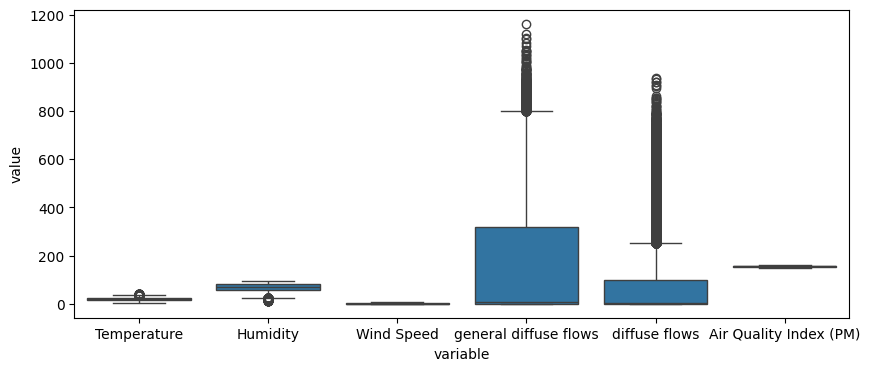

In [64]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='variable', y='value', data=features)
plt.show()

In [65]:
#Missing values imputation
features=['Temperature','Humidity','Wind Speed','general diffuse flows','diffuse flows','Air Quality Index (PM)']
for i in features:
  data[features]=data[features].fillna(data[features].median())

In [66]:
#After imputation
round(data.isnull().mean()*100,2)

,0
S no,0.0
Temperature,0.0
Humidity,0.0
Wind Speed,0.0
general diffuse flows,0.0
diffuse flows,0.0
Air Quality Index (PM),0.0
Cloudiness,0.0
Power Consumption in A Zone,0.0


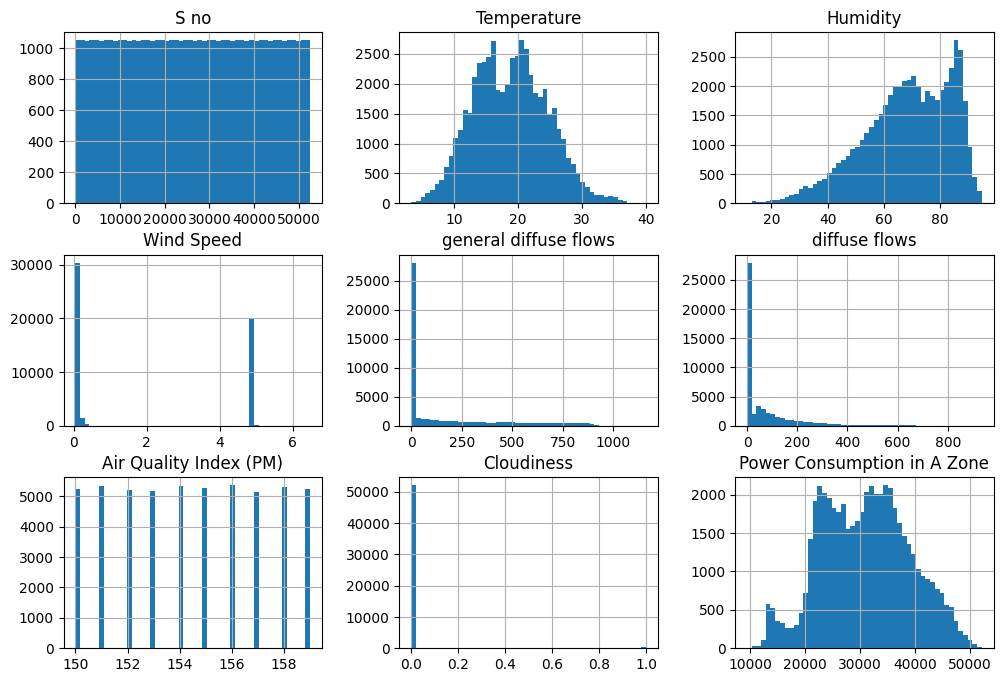

In [ ]:
#Univariate Analysis
data.hist(bins=50, figsize=(12, 8))
plt.show()

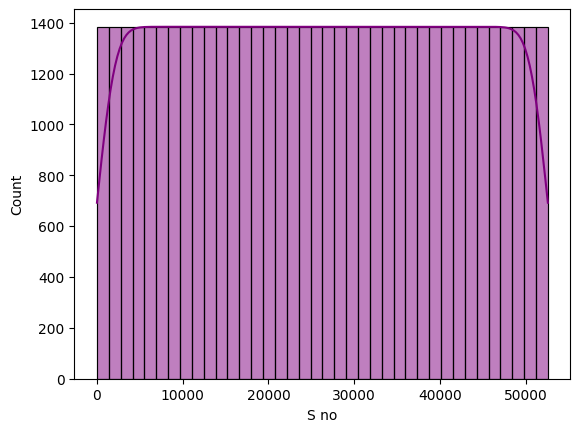

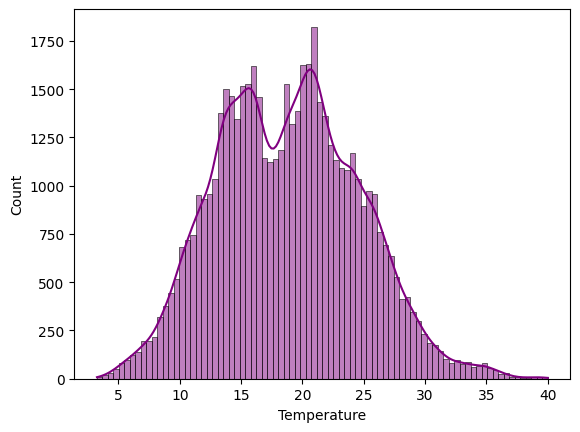

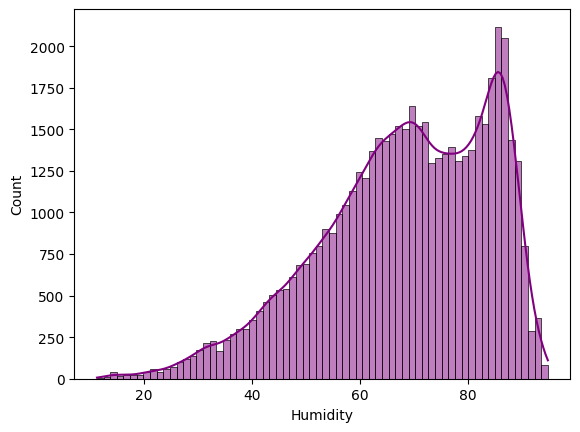

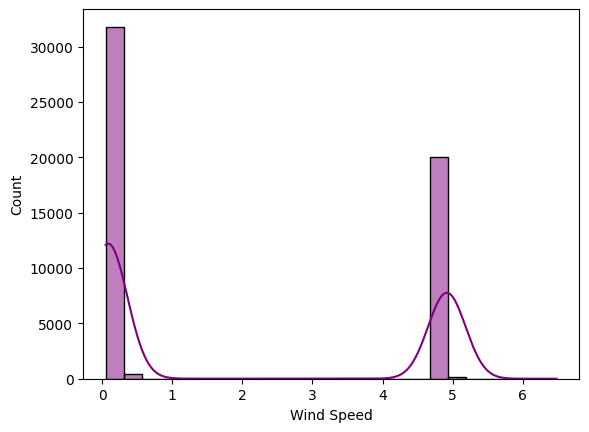

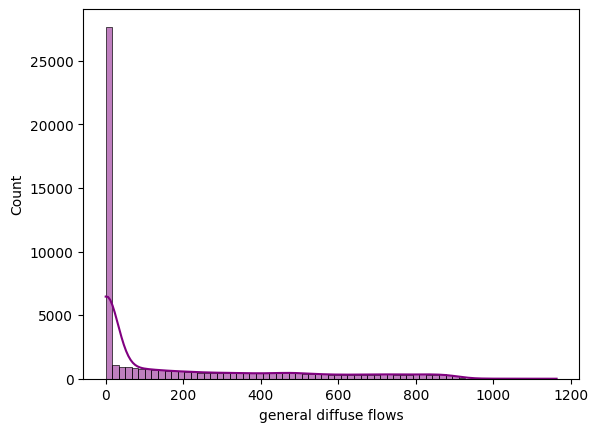

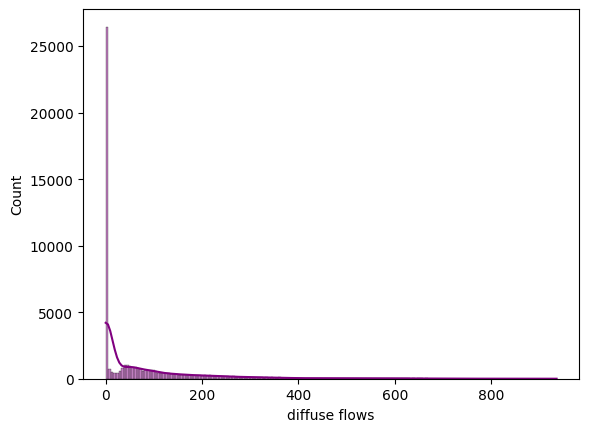

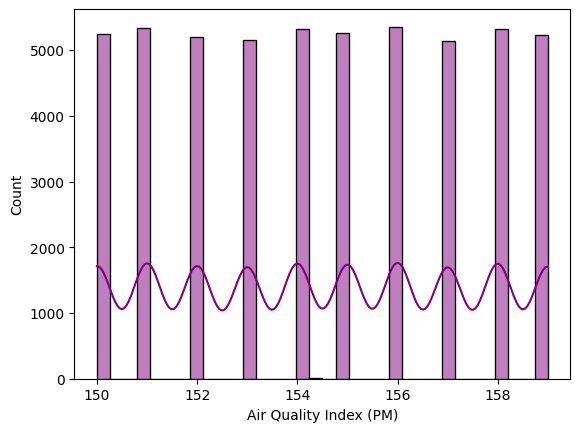

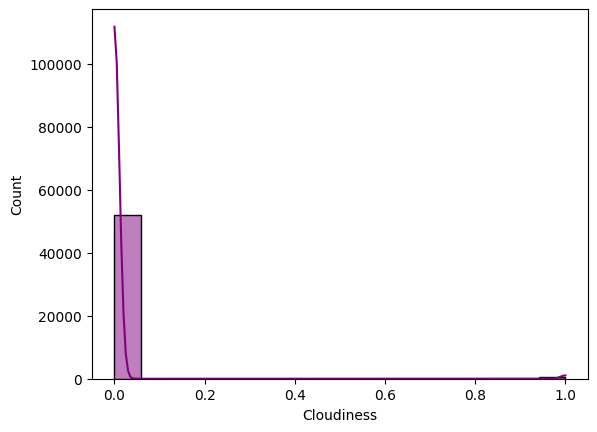

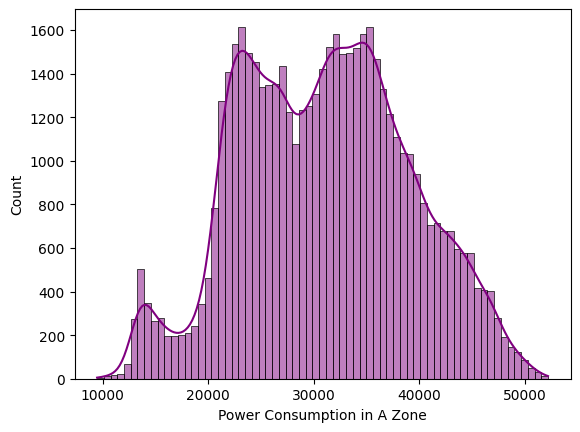

In [ ]:
for cols in data.columns:
 sns.histplot(data[cols],kde=True,color='purple')
 plt.show()

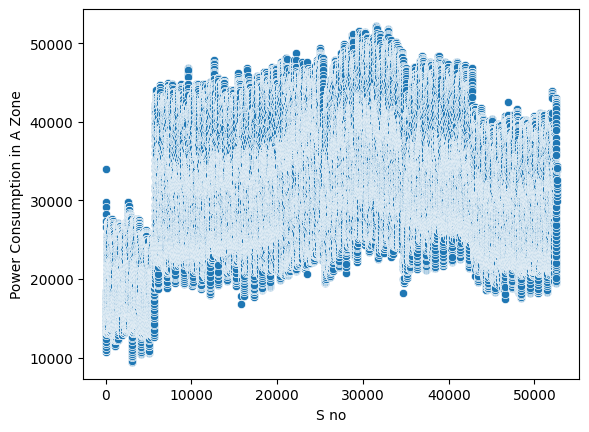

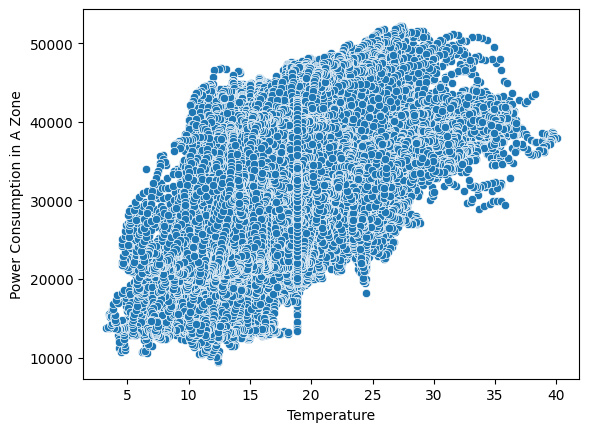

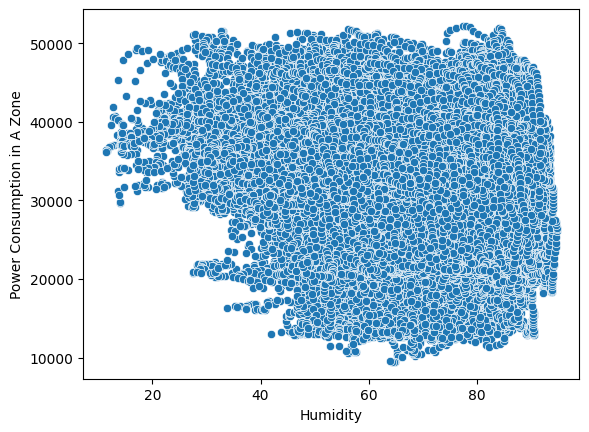

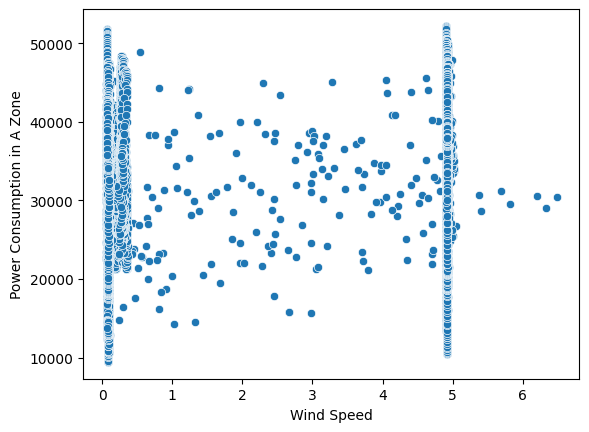

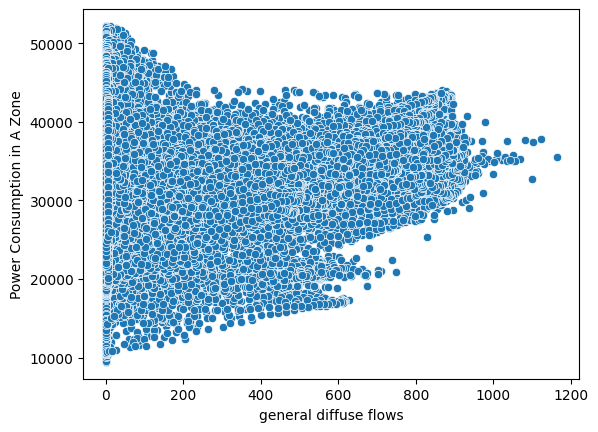

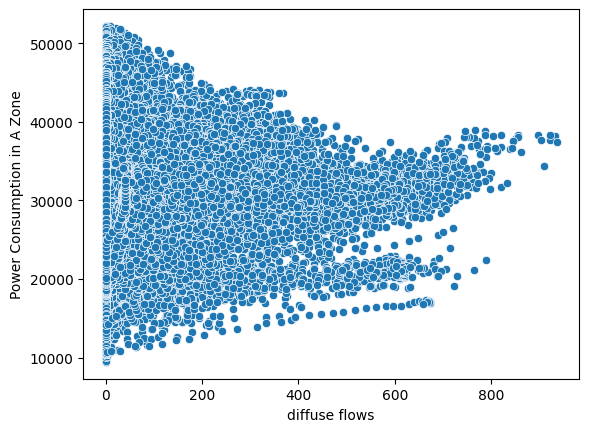

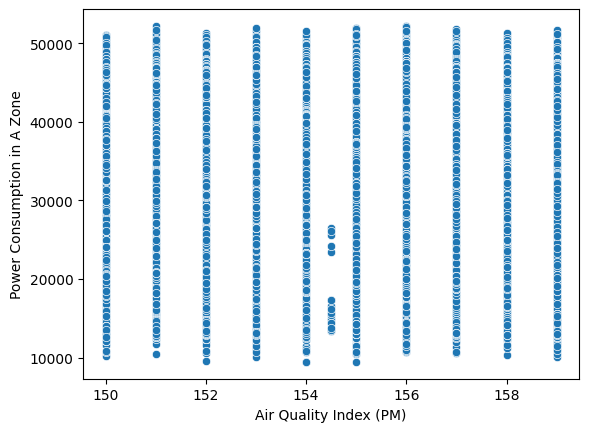

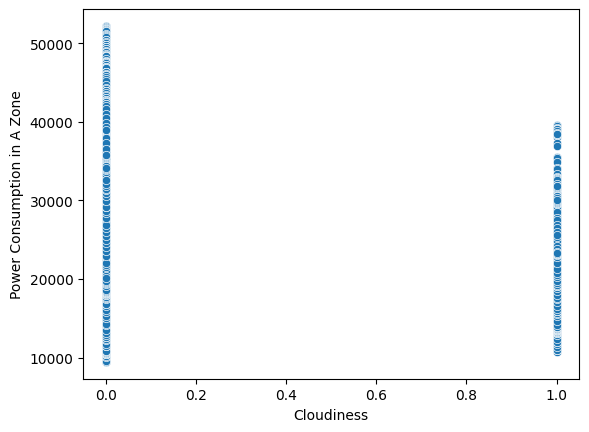

In [ ]:
#Bivariate Analysis
for i in data.columns:
  if i!='Power Consumption in A Zone':
    sns.scatterplot(x=i, y=data['Power Consumption in A Zone'], data=data)
    plt.show()

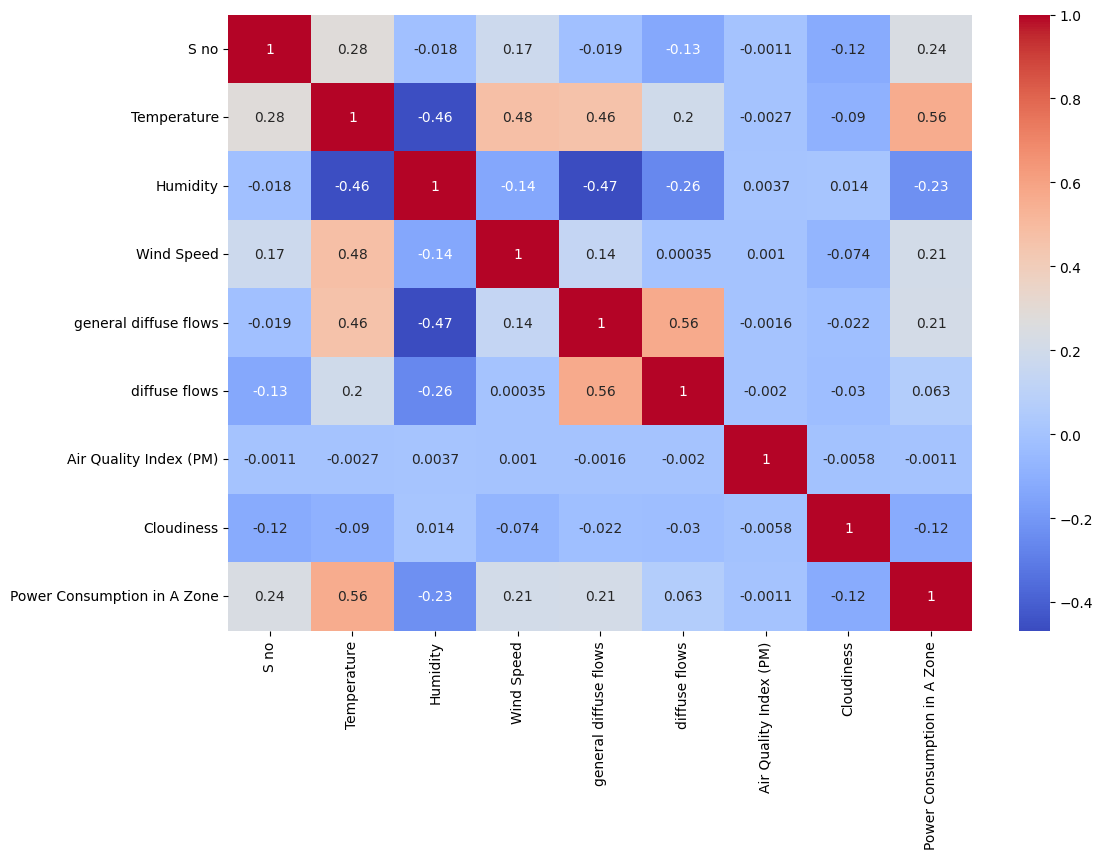

In [67]:
#Correlation
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.show()

<Axes: xlabel='S no', ylabel='Power Consumption in A Zone'>

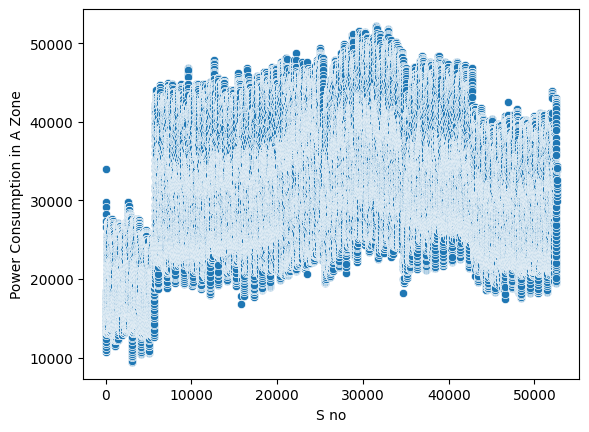

In [70]:
sns.scatterplot(data=data,x='S no',y='Power Consumption in A Zone',sizes=(100,500))

In [71]:
# Dependency split
x=data.iloc[:,:-1]
y=data['Power Consumption in A Zone']

In [72]:
#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [73]:
#Scaling the features
scale=MinMaxScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [74]:
#Building Linear regression model
lr_model=LinearRegression()
lr_model.fit(x_train_scaled,y_train)
y_pred_lr=lr_model.predict(x_test_scaled)

In [75]:
#Evaluation metrics
print("R² Score_LR :", round(r2_score(y_test, y_pred_lr),2))
print("MAE_LR     :", round(mean_absolute_error(y_test, y_pred_lr),2))
print("MSE_LR   :", round(mean_squared_error(y_test, y_pred_lr),2))
print("RMSE_LR  :", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)),2))

R² Score_LR : 0.33
MAE_LR     : 5267.5
MSE_LR   : 42963691.29
RMSE_LR  : 6554.67


In [76]:
#RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=200,oob_score=True,random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

In [77]:
#Validation using OOB
train_pred = rf_model.predict(x_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred_rf)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")
print(f"OOB R² Score: {rf_model.oob_score_:.4f}")

Train R²: 0.9905
Test R²:  0.9344
OOB R² Score: 0.9304


In [78]:
#Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(x_train,y_train)
y_pred_gb = gb_model.predict(x_test)

In [79]:
#XGBoost
xgb_model =XGBRegressor(n_estimators=200,learning_rate=0.01,max_depth=6,random_state=42)
xgb_model.fit(x_train,y_train)
y_pred_xgb=xgb_model.predict(x_test)

In [81]:
#Comparision between four models
models = pd.DataFrame({'Model':['Linear Regression','Gradient Boosting','XGBoost','Random Forest'],
                       'R_squared':  [r2_score(y_test,y_pred_lr),r2_score(y_test,y_pred_gb),r2_score(y_test,y_pred_xgb),r2_score(y_test,y_pred_rf)],
                       'MAE':[mean_absolute_error(y_test,y_pred_lr),mean_absolute_error(y_test,y_pred_gb),
                              mean_absolute_error(y_test,y_pred_xgb),mean_absolute_error(y_test,y_pred_rf)],
                      'RMSE':[np.sqrt(mean_squared_error(y_test,y_pred_lr)),
                              np.sqrt(mean_squared_error(y_test,y_pred_gb)),
                              np.sqrt(mean_squared_error(y_test,y_pred_xgb)),
                              np.sqrt(mean_squared_error(y_test,y_pred_rf))]})

models

,Model,R_squared,MAE,RMSE
0,Linear Regression,0.334924,5267.497877,6554.669427
1,Gradient Boosting,0.579473,4067.807253,5212.092628
2,XGBoost,0.588518,4056.641305,5155.736968
3,Random Forest,0.934357,1306.206671,2059.256531


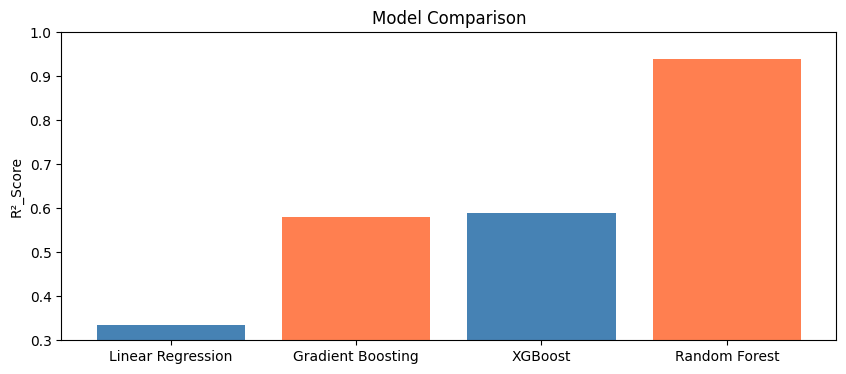

Best model: Random Forest with accuracy 0.9387


In [95]:
models = ['Linear Regression','Gradient Boosting','XGBoost','Random Forest']
R2_Score = [r2_score(y_test,y_pred_lr), r2_score(y_test,y_pred_gb),r2_score(y_test,y_pred_xgb),r2_score(y_test,y_pred_rf)]

plt.figure(figsize=(10, 4))
plt.bar(models, R2_Score, color=['steelblue', 'coral'])
plt.title('Model Comparison')
plt.ylabel('R²_Score')
plt.ylim(0.3, 1.0)
plt.show()

best = models[R2_Score.index(max(R2_Score))]
print(f"Best model: {best} with accuracy {max(R2_Score):.4f}")

Random Forest Regressor was selected as the final model because it achieved the highest R² score and lower prediction error compared to the other regression models evaluated.